In [67]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model


In [92]:
def build_float_to_boolean_encoder_only_voltage():
    input_layer = tf.keras.Input(shape=(1,), name="float_input")

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)
    # We'll adapt this normalization layer on the data later.
    x = input_layer

    # 2) Multiple Dense layers with ReLU
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # 20% dropout for regularization
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # 20% dropout for regularization
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # 20% dropout for regular
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # another dropout

    # 3) Final Dense layer (3 outputs), each with a sigmoid for binary classification
    outputs = layers.Dense(3, activation='sigmoid')(x)

    # 4) Build the model
    model = Model(inputs=input_layer, outputs=outputs)

    # 5) Compile the model (binary_crossentropy for multiple binary outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']  # This tracks how many individual bits match 0/1, not perfect for multi-bit, but still helpful
    )

    # Return both the model and the normalization layer (we need to .adapt() it)
    return model, norm




In [93]:
def build_float_to_boolean_encoder():
    # 1) Input layer for two float inputs
    input_layer = tf.keras.Input(shape=(2,), name="float_input")  # Shape (batch_size, 2)

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)  # Normalizes each feature independently
    # We'll adapt this normalization layer on the data later.
    x = norm(input_layer)

    # 2) Multiple Dense layers with ReLU

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # 20% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.2)(x)  # another dropout

    # 3) Final Dense layer (3 outputs), each with a sigmoid for binary classification
    outputs = layers.Dense(3, activation='sigmoid')(x)

    # 4) Build the model
    model = Model(inputs=input_layer, outputs=outputs)

    # 5) Compile the model (binary_crossentropy for multiple binary outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']  # Tracks the accuracy of individual bits (0/1)
    )

    # Return both the model and the normalization layer (we'll adapt it later)
    return model, norm



In [94]:
# Path to the folder containing the CSV files
def readDatasInPanda(file_paths):
#we probaply should not combine all the files in one dataset just now for testing
    folder_path = 'data'
    dataframes = []
    for file_path in file_paths: 
        print("read: " + file_path)
        df = pd.read_csv(file_path)
        
        # Append the cleaned DataFrame to the list
        dataframes.append(df)

# Combine all DataFrames into one
        pandas_data = pd.concat(dataframes, ignore_index=True)

# Display the first few rows of the combined DataFrame
    return pandas_data

In [95]:
df = readDatasInPanda(["./data/Circuit_Scenario4_res.csv", "./data/Circuit_Scenario5_res.csv", "./data/Circuit_Scenario6_res.csv", "./data/Circuit_Scenario7_res.csv",
                      "./data/Circuit_Scenario8_res.csv"])
df = readDatasInPanda(["./data/Circuit_ScenarioAllPairs_res.csv"])

read: ./data/Circuit_Scenario4_res.csv
read: ./data/Circuit_Scenario5_res.csv
read: ./data/Circuit_Scenario6_res.csv
read: ./data/Circuit_Scenario7_res.csv
read: ./data/Circuit_Scenario8_res.csv
read: ./data/Circuit_ScenarioAllPairs_res.csv


In [96]:
y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
# Convert output column to float as well:
X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
Y_binary = y - 1.0

#X

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_4 (Normalizat  (None, 2)                5         
 ion)                                                            
                                                                 
 dense_15 (Dense)            (None, 64)                192       
                                                                 
 dropout_9 (Dropout)         (None, 64)                0         
                                                                 
 dense_16 (Dense)            (None, 32)                2080      
                                                                 
 dropout_10 (Dropout)        (None, 32)                0         
                                                           

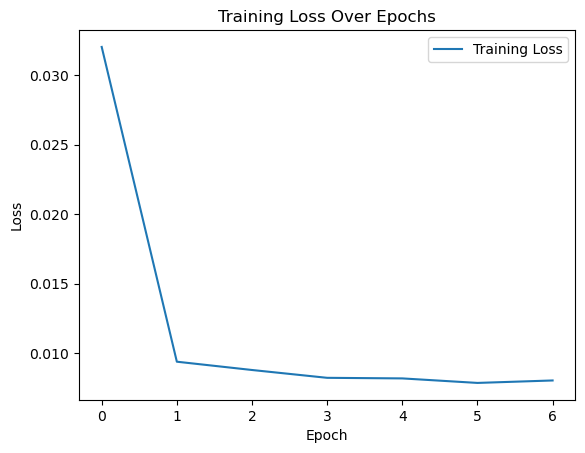

In [97]:
model, norm_layer = build_float_to_boolean_encoder()


    # We must "adapt" the normalization layer on our training data
norm_layer.adapt(X)

    # Print a summary
model.summary()

    # Train/fit the model
history = model.fit(
    X, 
    Y_binary, 
    epochs=7,        # Feel free to increase epochs
    batch_size=4,
    verbose=1
)

    # Optional: Plot the training loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

   

In [107]:
single_input = X[190]  # This is a single value, shape = (1,)

# Reshape to add batch dimension
single_input = single_input.reshape(1, -1)  # Shape = (1, 1)

# Predict for the single input
single_pred = model.predict(single_input)
preds_binary = (single_pred > 0.5).astype(int)
print("Raw Prediction:", preds_binary)


1/1 [==============================] - 0s 15ms/step
Raw Prediction: [[1 0 0]]


In [108]:
X #= X.reshape(-1, 1)
preds_raw = model.predict(X)  # shape = (num_samples, 3)
    # Threshold at 0.5 => 0 or 1
X
#preds_raw

2188/2188 [==============================] - 1s 548us/step


array([[  0.99009921,   1.        ],
       [  0.99009921,   1.        ],
       [  0.99009921,   1.        ],
       ...,
       [ 75.        , 100.        ],
       [  2.91262136,   1.        ],
       [  2.91262136,   1.        ]])

In [109]:
#predict faults. 
df_d = readDatasInPanda(["./data/Circuit_Scenario10_res.csv"])
#df_d

read: ./data/Circuit_Scenario10_res.csv


In [110]:
y_d = df_d[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
# Convert output column to float as well:
X_d = df_d[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
Y_binary_d = y_d - 1.0
#X_d

In [111]:
#X_d = X_d.reshape(-1, 1)
preds_raw_d = model.predict(X_d)
preds_binary_d = (preds_raw_d > 0.5).astype(int)

preds_binary_d
#Y_binary_d
for real, preds in zip(Y_binary_d, preds_binary_d):
    print(f"Real: {real} | Predictions: {preds}")
X_d


1/1 [==============================] - 0s 18ms/step
Real: [1. 0. 0.] | Predictions: [1 0 0]
Real: [1. 0. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 1 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictions: [1 0 0]
Real: [1. 1. 0.] | Predictio

array([[ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 66.66666778, 100.        ],
       [ 50.00000496, 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ],
       [ 50.000005  , 100.        ]])

In [112]:
#Compare prediction with fact 
#for elem in preds_binary_d:
#    print(preds_binary_d)

model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_4 (Normalizat  (None, 2)                5         
 ion)                                                            
                                                                 
 dense_15 (Dense)            (None, 64)                192       
                                                                 
 dropout_9 (Dropout)         (None, 64)                0         
                                                                 
 dense_16 (Dense)            (None, 32)                2080      
                                                                 
 dropout_10 (Dropout)        (None, 32)                0         
                                                           